In [ ]:
# impoort packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import seaborn as sns

In [ ]:
data = pd.read_csv('Breast_cancer_data.csv')
data.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


In [ ]:
data.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,1.000000


In [ ]:
data.isnull().sum()

mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 26.8 KB


In [ ]:
negative=data["diagnosis"].value_counts(0)[0]
positive=data["diagnosis"].value_counts(0)[1]
print(negative)
print(positive)

212
357


<ipython-input-137-ca97089d56ac>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=data, dodge=False, palette=['blue', 'red'])


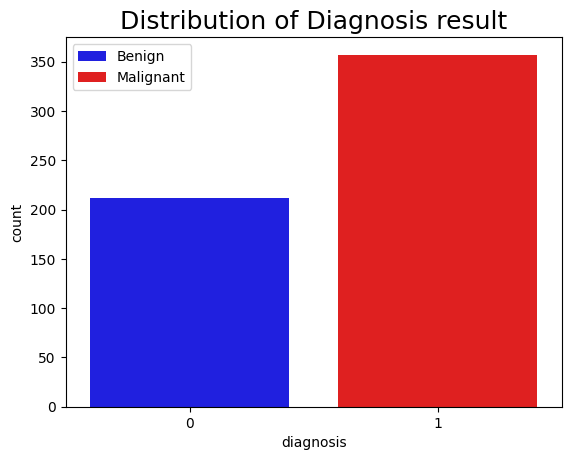

In [ ]:
sns.countplot(x='diagnosis', data=data, dodge=False, palette=['blue', 'red'])
plt.legend(['Benign', 'Malignant'])
plt.title('Distribution of Diagnosis result', fontsize=18)
plt.show()

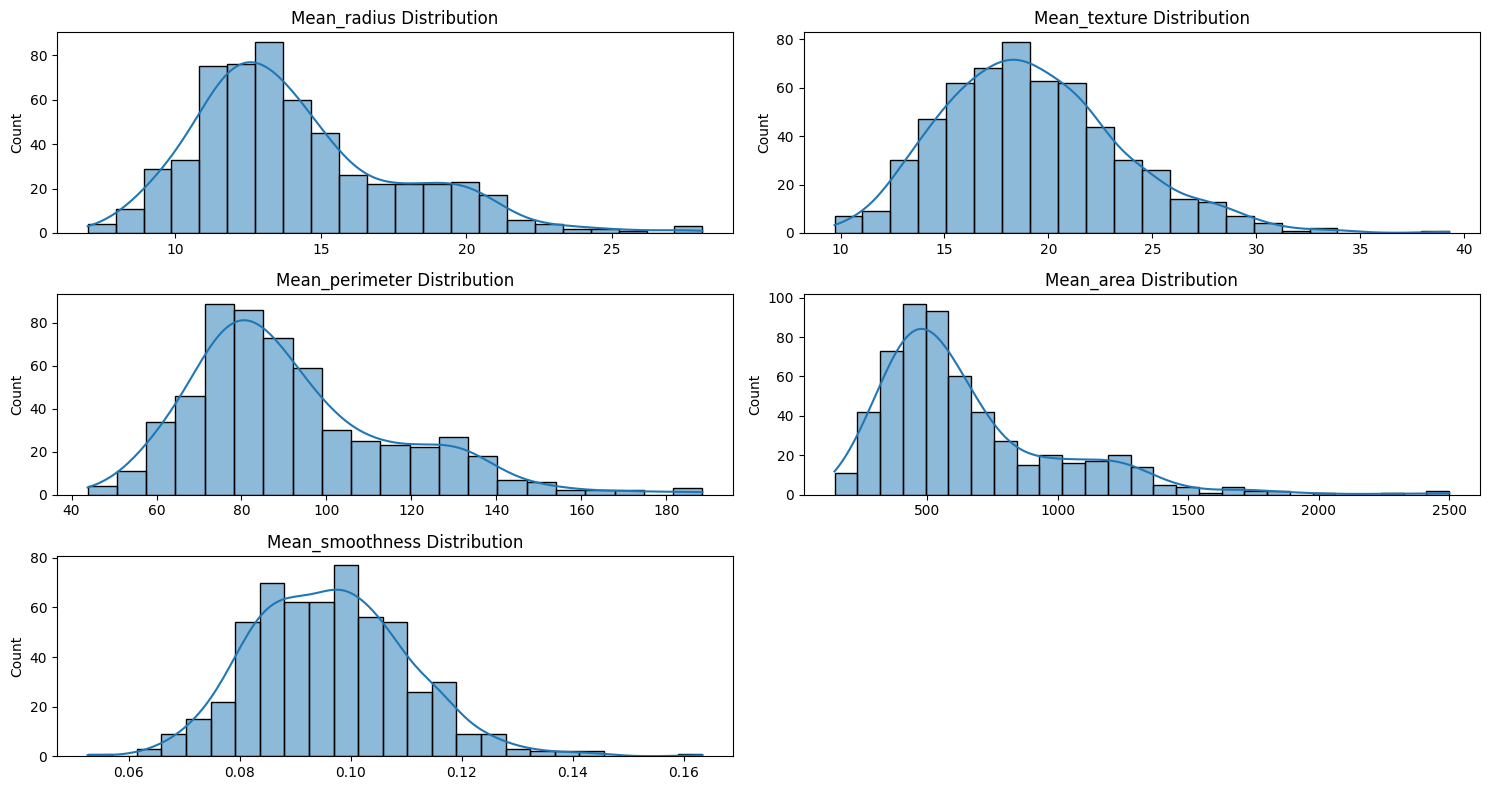

In [ ]:
x = data.drop("diagnosis", axis=1)
num_features = len(x.columns)
num_rows = (num_features + 1) // 2  # Calculate the number of rows needed
plt.figure(figsize=(15, 8))
for i, feature in enumerate(x, start=1):
    plt.subplot(num_rows, 2, i)
    sns.histplot(data=data, x=feature, kde=True)
    plt.title(f'{feature.capitalize()} Distribution')
    plt.xlabel('')
plt.tight_layout()
plt.show()

<Axes: >

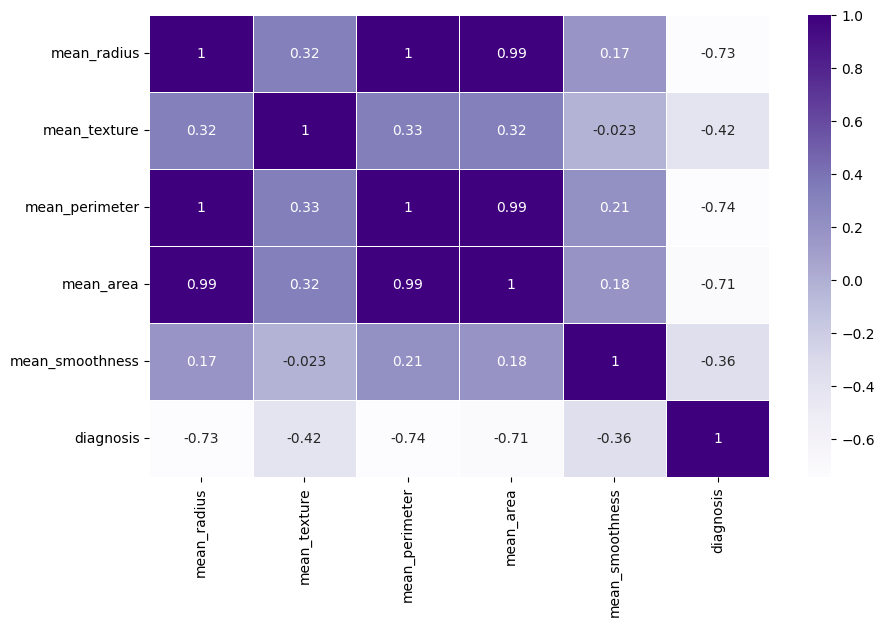

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(data.corr(), annot=True,linewidths=.5, cmap="Purples")

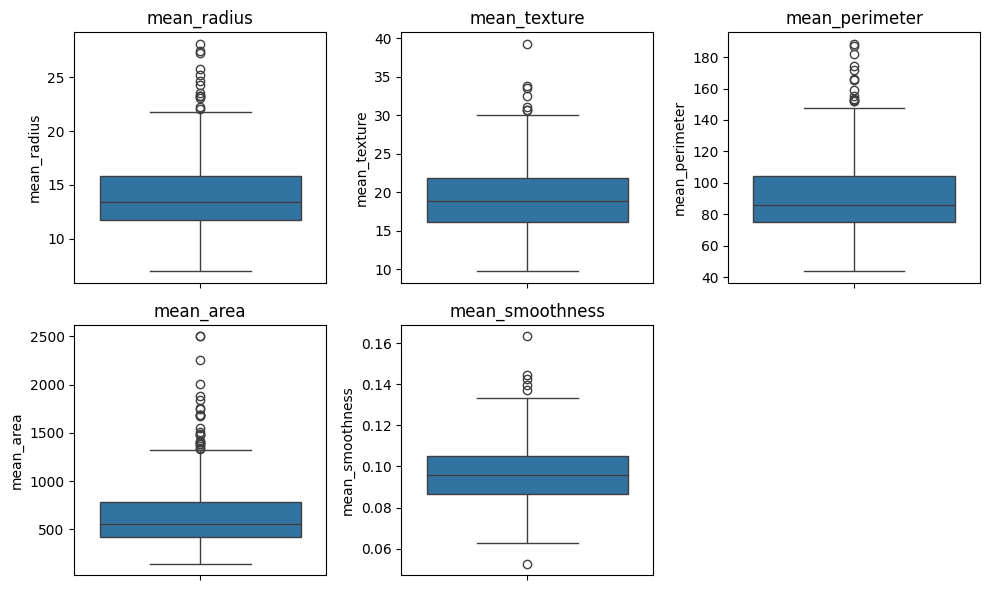

In [ ]:
features = ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness']
plt.figure(figsize=(10, 6))
for i, feature in enumerate(features, start=1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[feature])
    plt.title(feature)
plt.tight_layout()
plt.show()

In [ ]:
data = data.to_numpy()

X = data[:, :5]
y = data[:, 5]
print(X.shape)
print(y.shape)
from sklearn.model_selection import train_test_split

# Assuming 'X' contains the features and 'y' contains the labels
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

(569, 5)
(569,)
X_train shape: (455, 5)
X_test shape: (114, 5)
y_train shape: (455,)
y_test shape: (114,)


In [ ]:
# feature scaling
X_scaled = (X_train-X_train.mean(axis=0))/(X_train.max(axis=0)-X_train.min(axis=0))
X_scaled[:5]

tX = torch.tensor(X_scaled, dtype=torch.float32)
ty = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)

In [ ]:
X_new=torch.concat((torch.ones(len(X_scaled),1),tX),dim=1)
X_new[:5]

tensor([[ 1.0000, -0.2492, -0.0627, -0.2354, -0.1733,  0.0980],
        [ 1.0000,  0.3415,  0.2497,  0.3615,  0.2817,  0.1657],
        [ 1.0000, -0.2422, -0.1801, -0.2325, -0.1688, -0.1673],
        [ 1.0000, -0.1698,  0.2041, -0.1698, -0.1319,  0.0075],
        [ 1.0000, -0.1933, -0.1456, -0.1944, -0.1469,  0.1594]])

In [ ]:
# training
theta = torch.zeros((X_new.shape[1],1), dtype=torch.float32, requires_grad=True)
alpha = 10

for epoch in range(1, 1001):
  z = torch.matmul(X_new, theta)
  h = torch.sigmoid(z)

  cost = -ty*torch.log(h)-(1-ty)*torch.log(1-h)
  cost = cost.mean()

  # calculate derivatives
  cost.backward()

  # update parameters
  theta.requires_grad = False
  theta += -alpha * theta.grad
  theta.grad.zero_()
  theta.requires_grad = True

  if epoch%10 == 0:
    print(f'Epoch {epoch:02d}, Cost = {cost.item():0.4f}')

Epoch 10, Cost = 0.3279
Epoch 20, Cost = 0.2690
Epoch 30, Cost = 0.2434
Epoch 40, Cost = 0.2280
Epoch 50, Cost = 0.2175
Epoch 60, Cost = 0.2098
Epoch 70, Cost = 0.2040
Epoch 80, Cost = 0.1993
Epoch 90, Cost = 0.1956
Epoch 100, Cost = 0.1925
Epoch 110, Cost = 0.1900
Epoch 120, Cost = 0.1878
Epoch 130, Cost = 0.1860
Epoch 140, Cost = 0.1844
Epoch 150, Cost = 0.1831
Epoch 160, Cost = 0.1819
Epoch 170, Cost = 0.1808
Epoch 180, Cost = 0.1799
Epoch 190, Cost = 0.1791
Epoch 200, Cost = 0.1784
Epoch 210, Cost = 0.1777
Epoch 220, Cost = 0.1771
Epoch 230, Cost = 0.1766
Epoch 240, Cost = 0.1762
Epoch 250, Cost = 0.1757
Epoch 260, Cost = 0.1753
Epoch 270, Cost = 0.1750
Epoch 280, Cost = 0.1747
Epoch 290, Cost = 0.1744
Epoch 300, Cost = 0.1741
Epoch 310, Cost = 0.1739
Epoch 320, Cost = 0.1736
Epoch 330, Cost = 0.1734
Epoch 340, Cost = 0.1732
Epoch 350, Cost = 0.1731
Epoch 360, Cost = 0.1729
Epoch 370, Cost = 0.1728
Epoch 380, Cost = 0.1726
Epoch 390, Cost = 0.1725
Epoch 400, Cost = 0.1724
Epoch 410

In [ ]:
# Evaluate
h = torch.sigmoid(torch.matmul(X_new, theta))
tz = ty.clone()
tz[h>=0.5] = 1
tz[h<0.5] = 0

# prediction values
pred = []

# compare prediction and target
for i in range(len(y_train)):
    if tz[i] == 1:
        pred.append(1)
    else:
        pred.append(0)
    print(f'prediction = {pred[i]}, actual = {y_train[i]}')

accuracy = (tz == ty).float().mean()
print(f'Accuracy = {accuracy.item()*100:.2f}%')


prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 0, actual = 0.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 0, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 0, actual = 0.0
prediction = 0

In [ ]:
X_test_scaled = (X_test-X_test.mean(axis=0))/(X_test.max(axis=0)-X_test.min(axis=0))
X_test_scaled[:5]

array([[-0.09297842, -0.05486586, -0.08789788, -0.10091133,  0.01206172],
       [ 0.26175594,  0.07942552,  0.24496564,  0.27274102, -0.12685138],
       [ 0.07095601, -0.01125832,  0.07348337,  0.05302352,  0.15082952],
       [-0.09681635, -0.10045555, -0.08492239, -0.10904047,  0.09561302],
       [-0.14396805, -0.26101055, -0.13832463, -0.1464576 ,  0.01482255]])

In [ ]:
tX_test = torch.tensor(X_test_scaled, dtype=torch.float32)
ty_test = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)
X_new1=torch.concat((torch.ones(len(X_test),1),tX_test),dim=1)
X_new1[:5]

tensor([[ 1.0000, -0.0930, -0.0549, -0.0879, -0.1009,  0.0121],
        [ 1.0000,  0.2618,  0.0794,  0.2450,  0.2727, -0.1269],
        [ 1.0000,  0.0710, -0.0113,  0.0735,  0.0530,  0.1508],
        [ 1.0000, -0.0968, -0.1005, -0.0849, -0.1090,  0.0956],
        [ 1.0000, -0.1440, -0.2610, -0.1383, -0.1465,  0.0148]])

In [ ]:
tm = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)
tn = tm.clone()
h = torch.sigmoid(torch.matmul(X_new1, theta))
tn[h>=0.5] = 1
tn[h<0.5] = 0
# prediction values
pred_test = []

# compare prediction and target
for i in range(len(y_test)):
    if tn[i] == 1:
        pred_test.append(1)
    else:
        pred_test.append(0)
    print(f'prediction = {pred_test[i]}, actual = {y_test[i]}')
accuracy1 = (tn == tm).int().sum()/len(X_test)
print(f'Accuray = {accuracy1*100:.2f}%')

prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 0, actual = 0.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 0.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 0, actual = 0.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 1, actual = 1.0
prediction = 1

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
print(X_train.shape)
print(y_train.shape)

(455, 5)
(455,)


In [ ]:
model = LogisticRegression()

In [ ]:
model.fit(X_scaled, y_train)

LogisticRegression()

In [ ]:
z = model.predict(X_test_scaled)
accuray = (z==y_test).sum()/y_test.shape[0]
print(accuray)

0.9473684210526315
